<a href="https://colab.research.google.com/github/harshl3/Alpha-News/blob/main/Salary_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
df=pd.read_csv('/content/Salary Data (5).csv')




In [5]:
# Check for null values in each column
df.isnull().sum()

,0
Age,2
Gender,2
Education Level,2
Job Title,2
Years of Experience,2
Salary,2


In [6]:
# 1. Fill Numerical columns with Mean
num_cols = ['Age', 'Years of Experience', 'Salary']
for col in num_cols:
    df[col] = df[col].fillna(df[col].mean())

# 2. Fill Categorical columns with Mode
cat_cols = ['Gender', 'Education Level', 'Job Title']
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# 3. Verify that there are no more nulls
print(df.isnull().sum())

Age                    0
Gender                 0
Education Level        0
Job Title              0
Years of Experience    0
Salary                 0
dtype: int64


### Data Preprocessing for Model Training

Before training the linear regression model, we need to prepare the data:
1.  **Categorical Feature Encoding**: Convert categorical columns ('Gender', 'Education Level', 'Job Title') into numerical representations using one-hot encoding.
2.  **Define Features and Target**: Separate the DataFrame into features (X) and the target variable (y, which is 'Salary').
3.  **Train-Test Split**: Divide the dataset into training and testing sets to evaluate the model's performance on unseen data.

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Identify categorical and numerical features
categorical_features = ['Gender', 'Education Level', 'Job Title']
numerical_features = ['Age', 'Years of Experience']

# Create a column transformer for one-hot encoding categorical features
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough' # Keep numerical features as they are
)

# Create the pipeline: preprocessor + Linear Regression model
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

# Define features (X) and target (y)
X = df.drop('Salary', axis=1)
y = df['Salary']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data preparation complete. Training and testing sets created.")

Data preparation complete. Training and testing sets created.


### Training the Linear Regression Model

Now, we will train the `model_pipeline` using the training data (`X_train` and `y_train`). The pipeline will first apply the one-hot encoding to the categorical features and then fit the linear regression model.

In [8]:
# Train the model
model_pipeline.fit(X_train, y_train)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


### Model Evaluation

After training, we will evaluate the model's performance on the test set (`X_test` and `y_test`) using several metrics:
- **Mean Absolute Error (MAE)**: The average of the absolute differences between predictions and actual values.
- **Mean Squared Error (MSE)**: The average of the squared differences between predictions and actual values. Penalizes larger errors more.
- **Root Mean Squared Error (RMSE)**: The square root of the MSE, which is in the same units as the target variable.
- **R-squared (R2)**: Represents the proportion of the variance in the dependent variable that is predictable from the independent variables. A higher R2 indicates a better fit.

In [10]:
import numpy as np

# Make predictions on the test set
y_pred = model_pipeline.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse) # Calculate RMSE by taking the square root of MSE
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

Mean Absolute Error (MAE): 11844.76
Mean Squared Error (MSE): 336848228.61
Root Mean Squared Error (RMSE): 18353.43
R-squared (R2): 0.86


### Decision Tree Regressor

Now, let's train and evaluate a Decision Tree Regressor. Decision trees are non-parametric supervised learning methods used for classification and regression. The goal is to create a model that predicts the value of a target variable by learning simple decision rules inferred from the data features.

In [11]:
from sklearn.tree import DecisionTreeRegressor

# Create the pipeline for Decision Tree Regressor
dt_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', DecisionTreeRegressor(random_state=42))
])

# Train the Decision Tree model
dt_pipeline.fit(X_train, y_train)

# Make predictions on the test set
y_pred_dt = dt_pipeline.predict(X_test)

# Evaluate the Decision Tree model
mae_dt = mean_absolute_error(y_test, y_pred_dt)
mse_dt = mean_squared_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mse_dt)
r2_dt = r2_score(y_test, y_pred_dt)

print("Decision Tree Regressor Evaluation:")
print(f"Mean Absolute Error (MAE): {mae_dt:.2f}")
print(f"Mean Squared Error (MSE): {mse_dt:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_dt:.2f}")
print(f"R-squared (R2): {r2_dt:.2f}")

Decision Tree Regressor Evaluation:
Mean Absolute Error (MAE): 12592.30
Mean Squared Error (MSE): 454029859.93
Root Mean Squared Error (RMSE): 21307.98
R-squared (R2): 0.81


### Random Forest Regressor

Next, we will train and evaluate a Random Forest Regressor. Random Forest is an ensemble learning method that operates by constructing a multitude of decision trees at training time and outputting the mean prediction of the individual trees.

In [12]:
from sklearn.ensemble import RandomForestRegressor

# Create the pipeline for Random Forest Regressor
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(random_state=42))
])

# Train the Random Forest model
rf_pipeline.fit(X_train, y_train)

# Make predictions on the test set
y_pred_rf = rf_pipeline.predict(X_test)

# Evaluate the Random Forest model
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Regressor Evaluation:")
print(f"Mean Absolute Error (MAE): {mae_rf:.2f}")
print(f"Mean Squared Error (MSE): {mse_rf:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_rf:.2f}")
print(f"R-squared (R2): {r2_rf:.2f}")

Random Forest Regressor Evaluation:
Mean Absolute Error (MAE): 10739.90
Mean Squared Error (MSE): 313314480.33
Root Mean Squared Error (RMSE): 17700.69
R-squared (R2): 0.87


### K-Nearest Neighbors (KNN) Regressor

Now, let's implement and evaluate a K-Nearest Neighbors (KNN) Regressor. KNN is a non-parametric, lazy learning algorithm that estimates the value of a new data point based on the average of its 'k' nearest neighbors in the feature space.

In [13]:
from sklearn.neighbors import KNeighborsRegressor

# Create the pipeline for K-Nearest Neighbors Regressor
knn_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', KNeighborsRegressor(n_neighbors=5)) # Using 5 neighbors as a common starting point
])

# Train the KNN model
knn_pipeline.fit(X_train, y_train)

# Make predictions on the test set
y_pred_knn = knn_pipeline.predict(X_test)

# Evaluate the KNN model
mae_knn = mean_absolute_error(y_test, y_pred_knn)
mse_knn = mean_squared_error(y_test, y_pred_knn)
rmse_knn = np.sqrt(mse_knn)
r2_knn = r2_score(y_test, y_pred_knn)

print("K-Nearest Neighbors Regressor Evaluation:")
print(f"Mean Absolute Error (MAE): {mae_knn:.2f}")
print(f"Mean Squared Error (MSE): {mse_knn:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_knn:.2f}")
print(f"R-squared (R2): {r2_knn:.2f}")

K-Nearest Neighbors Regressor Evaluation:
Mean Absolute Error (MAE): 10279.76
Mean Squared Error (MSE): 204634344.06
Root Mean Squared Error (RMSE): 14305.05
R-squared (R2): 0.92


### Support Vector Machine (SVM) Regressor

Finally, we will train and evaluate a Support Vector Machine (SVM) Regressor. SVMs can perform non-linear regression using the kernel trick, implicitly mapping their inputs into high-dimensional feature spaces.

In [14]:
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler

# For SVMs, it's often beneficial to scale numerical features.
# Let's modify the preprocessor to include scaling for numerical features.
# We will redefine the preprocessor to apply StandardScaler to numerical features.

# Identify numerical features (already defined)
# numerical_features = ['Age', 'Years of Experience']

# Create a column transformer for one-hot encoding categorical features and scaling numerical features
preprocessor_svm = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('num', StandardScaler(), numerical_features) # Scale numerical features
    ],
    remainder='passthrough'
)

# Create the pipeline for SVR
# Note: SVR can be computationally expensive and sensitive to hyper-parameters.
svr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_svm),
    ('regressor', SVR(kernel='rbf')) # Using RBF kernel as a common starting point
])

# Train the SVR model
svr_pipeline.fit(X_train, y_train)

# Make predictions on the test set
y_pred_svr = svr_pipeline.predict(X_test)

# Evaluate the SVR model
mae_svr = mean_absolute_error(y_test, y_pred_svr)
mse_svr = mean_squared_error(y_test, y_pred_svr)
rmse_svr = np.sqrt(mse_svr)
r2_svr = r2_score(y_test, y_pred_svr)

print("Support Vector Machine Regressor Evaluation:")
print(f"Mean Absolute Error (MAE): {mae_svr:.2f}")
print(f"Mean Squared Error (MSE): {mse_svr:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_svr:.2f}")
print(f"R-squared (R2): {r2_svr:.2f}")

Support Vector Machine Regressor Evaluation:
Mean Absolute Error (MAE): 40709.74
Mean Squared Error (MSE): 2460949969.37
Root Mean Squared Error (RMSE): 49607.96
R-squared (R2): -0.02


### Model Comparison

Let's compare the performance of all the trained regression models based on their R-squared scores.

In [15]:
import pandas as pd

# Create a dictionary to store R2 scores
r2_scores = {
    'Linear Regression': r2,
    'Decision Tree Regressor': r2_dt,
    'Random Forest Regressor': r2_rf,
    'K-Nearest Neighbors Regressor': r2_knn,
    'Support Vector Machine Regressor': r2_svr
}

# Create a DataFrame from the dictionary
r2_df = pd.DataFrame(list(r2_scores.items()), columns=['Model', 'R2 Score'])

# Sort by R2 Score for better comparison
r2_df = r2_df.sort_values(by='R2 Score', ascending=False).reset_index(drop=True)

print("Model R-squared Scores:")
display(r2_df)

Model R-squared Scores:


,Model,R2 Score
0,K-Nearest Neighbors Regressor,0.915528
1,Random Forest Regressor,0.870665
2,Linear Regression,0.860950
3,Decision Tree Regressor,0.812578
4,Support Vector Machine Regressor,-0.015873


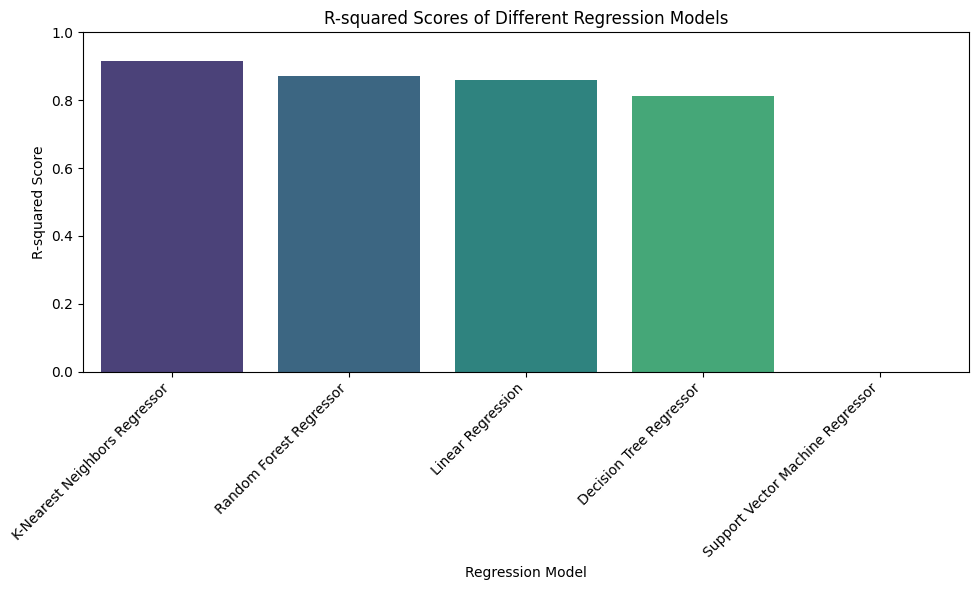

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='R2 Score', data=r2_df, hue='Model', palette='viridis', legend=False)
plt.title('R-squared Scores of Different Regression Models')
plt.xlabel('Regression Model')
plt.ylabel('R-squared Score')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1) # R2 scores typically range from 0 to 1, or can be negative for very poor models
plt.tight_layout()
plt.show()

### Model Comparison: Mean Squared Error (MSE)

Let's also compare the performance of all the trained regression models based on their Mean Squared Error (MSE).

In [16]:
# Create a dictionary to store MSE scores
mse_scores = {
    'Linear Regression': mse,
    'Decision Tree Regressor': mse_dt,
    'Random Forest Regressor': mse_rf,
    'K-Nearest Neighbors Regressor': mse_knn,
    'Support Vector Machine Regressor': mse_svr
}

# Create a DataFrame from the dictionary
mse_df = pd.DataFrame(list(mse_scores.items()), columns=['Model', 'MSE Score'])

# Sort by MSE Score (lower is better)
mse_df = mse_df.sort_values(by='MSE Score', ascending=True).reset_index(drop=True)

print("Model Mean Squared Error Scores:")
display(mse_df)

Model Mean Squared Error Scores:


,Model,MSE Score
0,K-Nearest Neighbors Regressor,2.046343e+08
1,Random Forest Regressor,3.133145e+08
2,Linear Regression,3.368482e+08
3,Decision Tree Regressor,4.540299e+08
4,Support Vector Machine Regressor,2.460950e+09


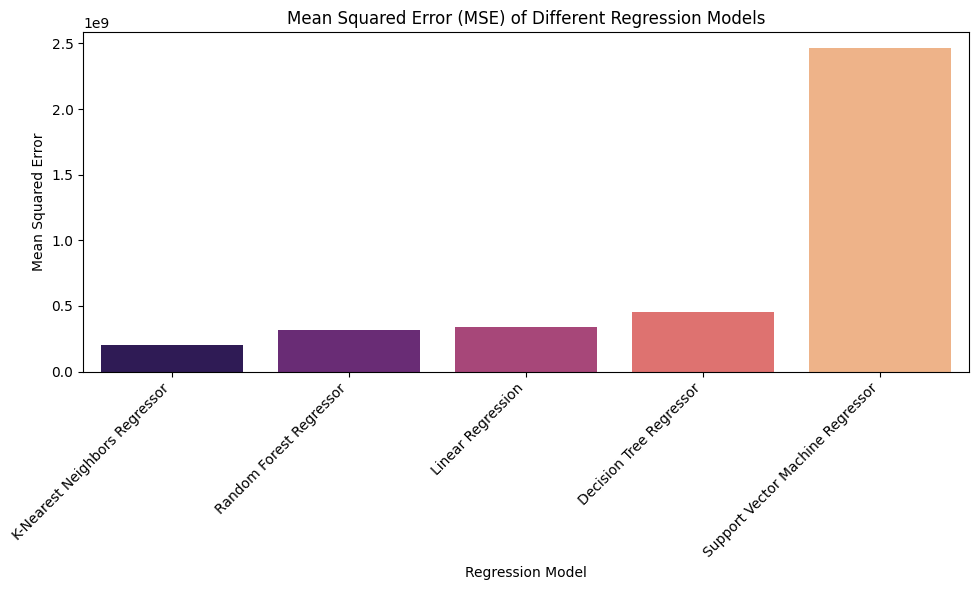

In [19]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='MSE Score', data=mse_df, hue='Model', palette='magma', legend=False)
plt.title('Mean Squared Error (MSE) of Different Regression Models')
plt.xlabel('Regression Model')
plt.ylabel('Mean Squared Error')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [20]:
import pickle

# Define the filename for the saved model
model_filename = 'best_knn_regressor_model.pkl'

# Save the best model (knn_pipeline) to a pickle file
with open(model_filename, 'wb') as file:
    pickle.dump(knn_pipeline, file)

print(f"Best model (K-Nearest Neighbors Regressor) saved as '{model_filename}'")

Best model (K-Nearest Neighbors Regressor) saved as 'best_knn_regressor_model.pkl'


### Generate `app.py` for Model Deployment

This cell will generate the content for an `app.py` file. You can copy this code and save it as `app.py` locally.

To run this Streamlit app:
1.  **Save the code:** Copy the content below into a file named `app.py`.
2.  **Ensure model is present:** Make sure `best_knn_regressor_model.pkl` is in the same directory as `app.py`.
3.  **Install Streamlit:** If you haven't already, install Streamlit: `pip install streamlit`
4.  **Run the app:** Open your terminal or command prompt, navigate to the directory where you saved `app.py`, and run: `streamlit run app.py`

In [21]:
%%writefile app.py
import streamlit as st
import pandas as pd
import pickle
import numpy as np

# Load the pre-trained model
try:
    with open('best_knn_regressor_model.pkl', 'rb') as file:
        model = pickle.load(file)
except FileNotFoundError:
    st.error("Model file 'best_knn_regressor_model.pkl' not found. Please ensure it's in the same directory.")
    st.stop()

st.title('Salary Prediction App')
st.write('Enter the details below to predict the salary.')

# Input fields for features
age = st.slider('Age', 18, 65, 30)
gender = st.selectbox('Gender', ['Male', 'Female', 'Other'])
education_level = st.selectbox('Education Level', ['Bachelor\'s', 'Master\'s', 'PhD'])
job_title = st.text_input('Job Title', 'Software Engineer')
years_of_experience = st.slider('Years of Experience', 0, 40, 5)

# Create a DataFrame from inputs
input_data = pd.DataFrame({
    'Age': [age],
    'Gender': [gender],
    'Education Level': [education_level],
    'Job Title': [job_title],
    'Years of Experience': [years_of_experience]
})

# Make prediction
if st.button('Predict Salary'):
    try:
        prediction = model.predict(input_data)
        st.success(f'Predicted Salary: ${prediction[0]:,.2f}')
    except Exception as e:
        st.error(f"An error occurred during prediction: {e}")
        st.write("Please check your input values and the model's expected features.")


Writing app.py


In [ ]:
deploy model

### Create `requirements.txt` for Streamlit Cloud Deployment

Streamlit Cloud requires a `requirements.txt` file to install all the necessary libraries for your application. This cell will generate a basic `requirements.txt` based on the libraries used in this notebook.

In [22]:
%%writefile requirements.txt
pandas
scikit-learn
streamlit
numpy
pickle-mixin

Writing requirements.txt


### Steps to Deploy to Streamlit Cloud

Now that you have your `app.py` and `requirements.txt` (and your `best_knn_regressor_model.pkl`), follow these steps to deploy your application to Streamlit Cloud:

1.  **Create a GitHub Repository**: Make sure your `app.py`, `best_knn_regressor_model.pkl`, and `requirements.txt` files are all committed and pushed to a public GitHub repository.

2.  **Go to Streamlit Cloud**: Visit [share.streamlit.io](https://share.streamlit.io/) and log in with your GitHub account.

3.  **Deploy an App**: Click on 'New app' or 'Deploy an app' button.

4.  **Connect to GitHub**: Select your GitHub repository from the dropdown list. You might need to authorize Streamlit to access your repositories.

5.  **Configure Deployment**:
    *   **Repository**: Select the GitHub repository where you pushed your files.
    *   **Branch**: Choose the branch (e.g., `main` or `master`).
    *   **Main file path**: Enter the path to your Streamlit app file (e.g., `app.py`).

6.  **Click 'Deploy!'**: Streamlit Cloud will then read your `requirements.txt`, install the dependencies, and launch your application.

Your app will be live and accessible via a unique URL provided by Streamlit Cloud!

### Predict Salary for a Custom Input

Based on your confirmation, let's predict the salary for a hypothetical individual with the following characteristics:
*   **Age:** 30
*   **Gender:** Male
*   **Education Level:** Bachelor's
*   **Job Title:** Software Engineer
*   **Years of Experience:** 6

In [23]:
# Create a DataFrame for the new prediction with the confirmed assumptions
new_data = pd.DataFrame({
    'Age': [30],
    'Gender': ['Male'],
    'Education Level': ['Bachelor\'s'],
    'Job Title': ['Software Engineer'],
    'Years of Experience': [6]
})

# Make the prediction using the trained KNN pipeline
predicted_salary = knn_pipeline.predict(new_data)

print(f"Predicted Salary for the given input: ${predicted_salary[0]:,.2f}")

Predicted Salary for the given input: $64,000.00
